# Basic Tests

In [1]:
import copy
import math
import pandas
from matplotlib import pyplot as plt
from py_ballisticcalc import TableG7, TableG1
from py_ballisticcalc import Ammo, Atmo, Wind
from py_ballisticcalc import Weapon, Shot, Calculator
from py_ballisticcalc import PreferredUnits
from py_ballisticcalc.drag_model import *
from py_ballisticcalc.unit import *
from py_ballisticcalc.trajectory_calc import *

print("Default units:\n"+str(PreferredUnits))  # Print default units

INFO:py_balcalc:Library running in pure python mode. For better performance install 'py_ballisticcalc.exts' package


Default units:
angular = degree
distance = yard
velocity = fps
pressure = inHg
temperature = fahrenheit
diameter = inch
length = inch
weight = grain
adjustment = mil
drop = inch
energy = foot-pound
ogw = pound
sight_height = inch
target_height = inch
twist = inch


In [2]:
zero = Shot(weapon=Weapon(sight_height=2), ammo=Ammo(DragModel(0.22, TableG7), mv=Velocity.FPS(2600)), relative_angle=Angular.Mil(1.33))
calc = Calculator()
zero_distance = Distance.Yard(100)
traj = calc.fire(zero, trajectory_range=zero_distance)
traj.dataframe(True).drop(['height', 'look_distance', 'density_factor', 'energy', 'ogw', 'flag'], axis=1).set_index('distance')

Running Euler integration...


,time,velocity,mach,target_drop,drop_adj,windage,windage_adj,angle,drag
distance,,,,,,,,,
0.0 yd,0.000 s,2600.0 ft/s,2.33 mach,-2.0 inch,0.000 mil,0.0 inch,0.000 mil,0.0748 °,0.000
10.0 yd,0.012 s,2579.4 ft/s,2.31 mach,-1.6 inch,-4.403 mil,0.0 inch,0.000 mil,0.0666 °,0.685
20.0 yd,0.023 s,2558.9 ft/s,2.29 mach,-1.2 inch,-1.647 mil,0.0 inch,0.000 mil,0.0582 °,0.682
30.0 yd,0.035 s,2538.5 ft/s,2.27 mach,-0.8 inch,-0.779 mil,0.0 inch,0.000 mil,0.0497 °,0.679
40.0 yd,0.047 s,2518.2 ft/s,2.26 mach,-0.5 inch,-0.383 mil,0.0 inch,0.000 mil,0.0410 °,0.676
50.0 yd,0.059 s,2497.9 ft/s,2.24 mach,-0.3 inch,-0.176 mil,0.0 inch,0.000 mil,0.0322 °,0.673
60.0 yd,0.071 s,2477.8 ft/s,2.22 mach,-0.1 inch,-0.064 mil,0.0 inch,0.000 mil,0.0233 °,0.670
70.0 yd,0.083 s,2457.7 ft/s,2.20 mach,-0.0 inch,-0.008 mil,0.0 inch,0.000 mil,0.0142 °,0.667
80.0 yd,0.095 s,2437.7 ft/s,2.18 mach,0.0 inch,0.015 mil,0.0 inch,0.000 mil,0.0050 °,0.664


In [3]:
set_calcMethod(CalcMethod.RK_dt)
zero = Shot(weapon=Weapon(sight_height=2), ammo=Ammo(DragModel(0.22, TableG7), mv=Velocity.FPS(2600)), relative_angle=Angular.Mil(1.33))
calc = Calculator()
zero_distance = Distance.Yard(100)
traj = calc.fire(zero, trajectory_range=zero_distance)
traj.dataframe(True).drop(['height', 'look_distance', 'density_factor', 'energy', 'ogw', 'flag'], axis=1).set_index('distance')

Running RK4 dt integration...


,time,velocity,mach,target_drop,drop_adj,windage,windage_adj,angle,drag
distance,,,,,,,,,
0.0 yd,0.000 s,2600.0 ft/s,2.33 mach,-2.0 inch,0.000 mil,0.0 inch,0.000 mil,0.0748 °,0.000
10.0 yd,0.012 s,2579.4 ft/s,2.31 mach,-1.6 inch,-4.401 mil,0.0 inch,0.000 mil,0.0666 °,0.685
20.0 yd,0.023 s,2558.9 ft/s,2.29 mach,-1.2 inch,-1.646 mil,0.0 inch,0.000 mil,0.0582 °,0.682
30.0 yd,0.035 s,2538.5 ft/s,2.27 mach,-0.8 inch,-0.777 mil,0.0 inch,0.000 mil,0.0497 °,0.679
40.0 yd,0.047 s,2518.2 ft/s,2.26 mach,-0.5 inch,-0.381 mil,0.0 inch,0.000 mil,0.0410 °,0.676
50.0 yd,0.059 s,2497.9 ft/s,2.24 mach,-0.3 inch,-0.175 mil,0.0 inch,0.000 mil,0.0322 °,0.673
60.0 yd,0.071 s,2477.8 ft/s,2.22 mach,-0.1 inch,-0.063 mil,0.0 inch,0.000 mil,0.0233 °,0.670
70.0 yd,0.083 s,2457.7 ft/s,2.20 mach,-0.0 inch,-0.006 mil,0.0 inch,0.000 mil,0.0142 °,0.667
80.0 yd,0.095 s,2437.8 ft/s,2.18 mach,0.0 inch,0.016 mil,0.0 inch,0.000 mil,0.0050 °,0.664


In [4]:
set_calcMethod(CalcMethod.RK_dx)
zero = Shot(weapon=Weapon(sight_height=2), ammo=Ammo(DragModel(0.22, TableG7), mv=Velocity.FPS(2600)), relative_angle=Angular.Mil(1.33))
calc = Calculator()
zero_distance = Distance.Yard(100)
traj = calc.fire(zero, trajectory_range=zero_distance)
traj.dataframe(True).drop(['height', 'look_distance', 'density_factor', 'energy', 'ogw', 'flag'], axis=1).set_index('distance')

Running RK4 dx integration...


,time,velocity,mach,target_drop,drop_adj,windage,windage_adj,angle,drag
distance,,,,,,,,,
0.0 yd,0.000 s,2600.0 ft/s,2.33 mach,-2.0 inch,0.000 mil,0.0 inch,0.000 mil,0.0748 °,0.000
10.0 yd,0.012 s,2579.4 ft/s,2.31 mach,-1.6 inch,-4.401 mil,0.0 inch,0.000 mil,0.0666 °,0.685
20.0 yd,0.023 s,2558.9 ft/s,2.29 mach,-1.2 inch,-1.646 mil,0.0 inch,0.000 mil,0.0582 °,0.682
30.0 yd,0.035 s,2538.5 ft/s,2.27 mach,-0.8 inch,-0.777 mil,0.0 inch,0.000 mil,0.0497 °,0.679
40.0 yd,0.047 s,2518.2 ft/s,2.26 mach,-0.5 inch,-0.381 mil,0.0 inch,0.000 mil,0.0410 °,0.676
50.0 yd,0.059 s,2497.9 ft/s,2.24 mach,-0.3 inch,-0.175 mil,0.0 inch,0.000 mil,0.0322 °,0.673
60.0 yd,0.071 s,2477.8 ft/s,2.22 mach,-0.1 inch,-0.063 mil,0.0 inch,0.000 mil,0.0233 °,0.670
70.0 yd,0.083 s,2457.7 ft/s,2.20 mach,-0.0 inch,-0.006 mil,0.0 inch,0.000 mil,0.0142 °,0.667
80.0 yd,0.095 s,2437.8 ft/s,2.18 mach,0.0 inch,0.016 mil,0.0 inch,0.000 mil,0.0050 °,0.664


# Degradation Tests
## RK4 dx

In [2]:
set_calcMethod(CalcMethod.RK_dx)
zero = Shot(weapon=Weapon(sight_height=2), ammo=Ammo(DragModel(0.22, TableG7), mv=Velocity.FPS(2600)), relative_angle=Angular.Mil(13))
calc = Calculator()
r = []
for step in [1, 3, 15, 30, 60, 150, 300, 600]:
    set_global_max_calc_step_size(Distance.Foot(step))
    traj = calc.fire(zero, trajectory_range=Distance.Yard(1000))
    dff = traj.dataframe(True).drop(['height', 'windage', 'mach', 'drop_adj', 'windage_adj', 'look_distance', 'density_factor', 'energy', 'ogw', 'flag'], axis=1).iloc[-1:]
    dff['StepSize'] = step
    r.append(dff)
df = pandas.concat(r)
df.set_index('StepSize', inplace=True)
df.to_clipboard()
df

Running RK4 integration with dx=0.5...
Running RK4 integration with dx=1.5...
Running RK4 integration with dx=7.5...
Running RK4 integration with dx=15.0...
Running RK4 integration with dx=30.0...
Running RK4 integration with dx=75.0...
Running RK4 integration with dx=150.0...
Running RK4 integration with dx=300.0...


,time,distance,velocity,target_drop,angle,drag
StepSize,,,,,,
1,1.891 s,1000.0 yd,1029.6 ft/s,-56.6 inch,-1.6400 °,0.159
3,1.890 s,1000.0 yd,1029.5 ft/s,-56.3 inch,-1.6399 °,0.159
15,1.888 s,1000.0 yd,1029.3 ft/s,-54.6 inch,-1.6391 °,0.160
30,1.886 s,1000.0 yd,1028.9 ft/s,-52.5 inch,-1.6381 °,0.161
60,1.880 s,1000.0 yd,1028.1 ft/s,-48.4 inch,-1.6362 °,0.162
150,1.865 s,1000.0 yd,1026.4 ft/s,-36.0 inch,-1.6296 °,0.169
300,1.838 s,1000.0 yd,1022.4 ft/s,-15.9 inch,-1.6185 °,0.177
600,1.783 s,1000.0 yd,1000.8 ft/s,22.8 inch,-1.5963 °,0.353


In [2]:
set_calcMethod(CalcMethod.RK_dt)
zero = Shot(weapon=Weapon(sight_height=2), ammo=Ammo(DragModel(0.22, TableG7), mv=Velocity.FPS(2600)), relative_angle=Angular.Mil(13))
calc = Calculator()
r = []
for step in [1, 3, 15, 30, 60, 150, 300, 600]:
    set_global_max_calc_step_size(Distance.Foot(step))
    traj = calc.fire(zero, trajectory_range=Distance.Yard(1000))
    dff = traj.dataframe(True).drop(['height', 'windage', 'mach', 'drop_adj', 'windage_adj', 'look_distance', 'density_factor', 'energy', 'ogw', 'flag'], axis=1).iloc[-1:]
    dff['StepSize'] = step
    r.append(dff)
df = pandas.concat(r)
df.set_index('StepSize', inplace=True)
df.to_clipboard()
df

Running RK4 dt integration with initial time-step 0.00019232335558476624...
Running RK4 dt integration with initial time-step 0.0005769700667542987...
Running RK4 dt integration with initial time-step 0.0028848503337714935...
Running RK4 dt integration with initial time-step 0.005769700667542987...
Running RK4 dt integration with initial time-step 0.011539401335085974...
Running RK4 dt integration with initial time-step 0.028848503337714937...
Running RK4 dt integration with initial time-step 0.057697006675429874...
Running RK4 dt integration with initial time-step 0.11539401335085975...


,time,distance,velocity,target_drop,angle,drag
StepSize,,,,,,
1,1.891 s,1000.2 yd,1029.6 ft/s,-56.5 inch,-1.6396 °,0.159
3,1.890 s,1000.5 yd,1029.6 ft/s,-56.1 inch,-1.6387 °,0.159
15,1.887 s,1002.4 yd,1029.8 ft/s,-53.9 inch,-1.6330 °,0.160
30,1.883 s,1004.7 yd,1030.1 ft/s,-51.1 inch,-1.6260 °,0.162
60,1.876 s,1009.4 yd,1030.5 ft/s,-45.5 inch,-1.6119 °,0.165
150,1.853 s,1023.6 yd,1031.5 ft/s,-28.7 inch,-1.5699 °,0.177
300,1.816 s,1046.9 yd,1034.3 ft/s,-1.2 inch,-1.4998 °,0.217
600,1.744 s,1092.9 yd,1043.2 ft/s,51.9 inch,-1.3631 °,0.399


## Euler

In [4]:
set_calcMethod(CalcMethod.Euler)
zero = Shot(weapon=Weapon(sight_height=2), ammo=Ammo(DragModel(0.22, TableG7), mv=Velocity.FPS(2600)), relative_angle=Angular.Mil(13))
calc = Calculator()
r = []
for step in [1, 3, 15, 30, 60, 150, 300, 600]:
    set_global_max_calc_step_size(Distance.Foot(step))
    traj = calc.fire(zero, trajectory_range=Distance.Yard(1000))
    dff = traj.dataframe(True).drop(['height', 'mach', 'drop_adj', 'windage_adj', 'look_distance', 'density_factor', 'energy', 'ogw', 'flag'], axis=1).iloc[-1:]
    dff['StepSize'] = step
    r.append(dff)
df = pandas.concat(r)
df.set_index('StepSize', inplace=True)
df.to_clipboard()
df

Running Euler integration with initial time-step 0.00019232335558476624...
Running Euler integration with initial time-step 0.0005769700667542987...
Running Euler integration with initial time-step 0.0028848503337714935...
Running Euler integration with initial time-step 0.005769700667542987...
Running Euler integration with initial time-step 0.011539401335085974...
Running Euler integration with initial time-step 0.028848503337714937...
Running Euler integration with initial time-step 0.057697006675429874...
Running Euler integration with initial time-step 0.11539401335085975...


,time,distance,velocity,target_drop,windage,angle,drag
StepSize,,,,,,,
1,1.891 s,1000.0 yd,1029.5 ft/s,-56.8 inch,0.0 inch,-1.6403 °,0.159
3,1.891 s,1000.0 yd,1029.4 ft/s,-57.1 inch,0.0 inch,-1.6406 °,0.159
15,1.894 s,1000.0 yd,1028.7 ft/s,-58.7 inch,0.0 inch,-1.6424 °,0.159
30,1.897 s,1000.0 yd,1027.9 ft/s,-60.7 inch,0.0 inch,-1.6446 °,0.160
60,1.903 s,1000.0 yd,1026.1 ft/s,-64.8 inch,0.0 inch,-1.6492 °,0.160
150,1.921 s,1000.0 yd,1020.3 ft/s,-76.8 inch,0.0 inch,-1.6634 °,0.162
300,1.952 s,1000.0 yd,1011.7 ft/s,-96.4 inch,0.0 inch,-1.6858 °,0.168
600,2.016 s,1000.0 yd,997.7 ft/s,-134.5 inch,0.0 inch,-1.7277 °,0.196


# SciPy
## .solve_ivp
### dv/dt

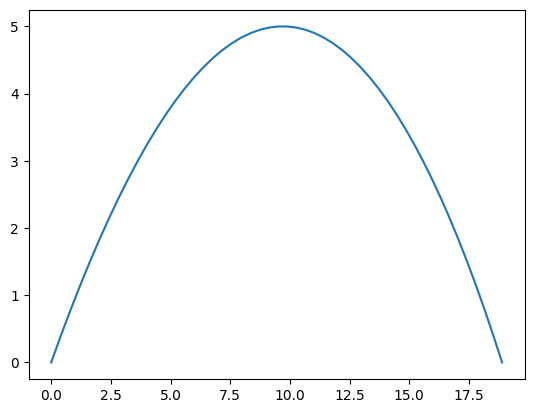

The solver successfully reached the end of the integration interval. with 38 function calls.


In [27]:
import numpy as np
from scipy.integrate import solve_ivp

# y = [x, y, vx, vy]
def f(t: float, d):  # dv/dt
    """Right-hand side of the differential equation."""
    speed = np.sqrt(d[2]**2+d[3]**2)
    return np.array([d[2], d[3], -0.05 * speed, -10])

# Initial conditions: v in m/s
y0 = np.array([0, 0, 10, 10])

# Time span
t_span = [0, 2]

# Solve the IVP
sol = solve_ivp(f, t_span, y0, dense_output=True)

# Plot the solution
import matplotlib.pyplot as plt
z = sol.sol(np.linspace(0,2,50))
#plt.plot(sol.y[0], sol.y[1])
plt.plot(z[0], z[1])
plt.show()
print(f'{sol.message} with {sol.nfev} function calls.')

### dv/dx

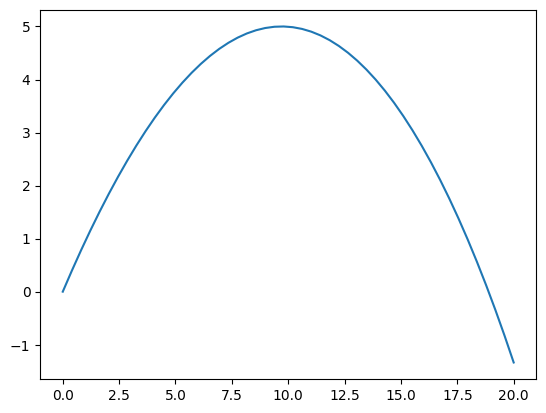

The solver successfully reached the end of the integration interval. with 38 function calls.
At x=20 y=-1.335002456277901 at t=2.1256444682479216


In [57]:
# y = [t, y, vx, vy]
def f(x: float, d):  # dv/dx
    """Right-hand side of the differential equation."""
    vx = d[2]
    speed = np.sqrt(vx**2+d[3]**2)
    return np.array([1/vx, d[3]/vx, -0.05 * speed / vx, -10 / vx])

# Initial conditions: v in m/s
y0 = np.array([0, 0, 10, 10])

# x span
x_span = [0, 20]

# Solve the IVP
sol = solve_ivp(f, x_span, y0, dense_output=True)

# Plot the solution
import matplotlib.pyplot as plt
x = np.linspace(0,20,50)
z = sol.sol(x)
#plt.plot(sol.y[0], sol.y[1])
plt.plot(x, z[1])
plt.show()
print(f'{sol.message} with {sol.nfev} function calls.')
print(f'At x={x_span[1]} y={sol.y[1][-1]} at t={sol.y[0][-1]}')

#### Manual

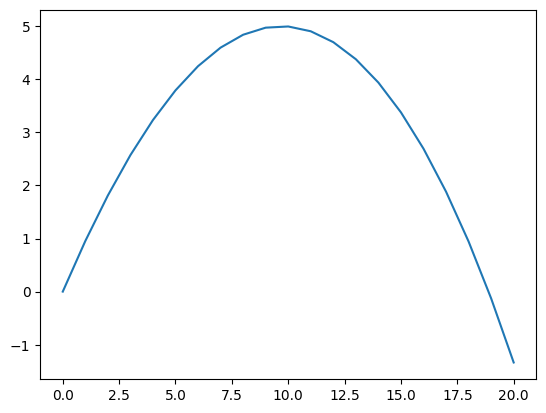

At x=20 y=-1.3350379362624996 at t=2.125614312763946


In [77]:
# y = [t, y, vx, vy]
def f(x: float, d):  # dv/dx
    vx = d[2]
    speed = np.sqrt(vx**2+d[3]**2)
    return np.array([1/vx, d[3]/vx, -0.05 * speed / vx, -10 / vx])

# Initial conditions: v in m/s
y = np.array([0, 0, 10, 10])
x = 0
r = [y,]

dx = 1
while x < 20:
    x += dx
    k1 = f(dx, y)
    k2 = f(dx, y + 0.5 * dx * k1)
    k3 = f(dx, y + 0.5 * dx * k2)
    k4 = f(dx, y + dx * k3)
    y = y + (k1 + 2*k2 + 2*k3 + k4) * (dx/6)
    r.append(y)

# Plot the solution
plotX = np.arange(0,21,dx)
plt.plot(plotX, [a[1] for a in r])
plt.show()
print(f'At x={x} y={r[-1][1]} at t={r[-1][0]}')

In [44]:
import math
velocity = 2600
x0 = np.array([0, 0, velocity * math.cos(Angular.Mil(13) >> Angular.Radian), velocity * math.sin(Angular.Mil(13) >> Angular.Radian), 0])

def f(x, d):  # d/dx
    # d = y, z, vx, vy, vz
    speed = np.linalg.norm(d[2:])
    drag = 0.15 * speed #density_factor * self.drag_by_mach(speed / mach)
    return np.array([d[3]/d[2], d[4]/d[2], -drag/d[2], -32/d[2], 0])

sol = solve_ivp(f, [0, 3000], x0)#, dense_output=True)
print(f'{sol.message} with {sol.nfev} function calls.')


The solver successfully reached the end of the integration interval. with 38 function calls.
